# Script 1:

This script uses the P- and S-wave picks from a catalogued earthquake to retrieve the waveforms from the continuous data. Then, it creates a template event usable in a subsequent matched filter search. This script can be generalized to generate a database of template events using a whole earthquake catalog.

In [1]:
import sys
import os
sys.path.append(os.getcwd())
from collections import defaultdict
import h5py as h5
import numpy as np
import utils
import math
from obspy.core import UTCDateTime as udt
import matplotlib.pyplot as plt

In [ ]:
# 获取当前工作目录下的所有子文件夹
base_sac_path = './sac_data/'
output_base_path = './h5/'

# 定义感兴趣的 station 文件夹
sac_stations = ['Xs28']
# 遍历每个 station 文件夹
for sac_station in sac_stations:
	# 构建完整的 station 路径
	station_path = os.path.join(base_sac_path, sac_station)

	# 获取该 station 下的所有 SAC 文件
	sac_files = [f for f in os.listdir(station_path) if f.endswith(('.EPE', '.EPN', '.EPZ'))]
	date_to_files = defaultdict(list)
	for filename in sac_files:
		file_path = os.path.join(station_path, filename)
		parts = filename.split('.')
		if len(parts) >= 3 and parts[2] == sac_station:  # 确保是当前 station
			event_date = parts[1]  # 提取日期部分，如 "20230909"
			date_to_files[event_date].append(file_path)

	# 处理每个日期下的文件
	for event_date, file_list in date_to_files.items():
		if len(file_list) % 3 != 0:
			print(f"不完整的数据集：{event_date} 在 {sac_station}")
			continue
		# 加载 SAC 数据（传入文件路径列表和事件名称）
		utils.load_sac_data(file_list, f"{event_date}_{sac_station}",path=f'{output_base_path}{sac_station}/')
		# 加载生成的数据
		data = utils.load_data(f"{event_date}_{sac_station}.h5",path=f'{output_base_path}{sac_station}/')
		print('Elements in data:\n', data.keys())
		print('metadata is also a Python dictionary:\n', data['metadata'].keys())
		print('\n')
		print('data station:',data['metadata']['stations'])
		print('data components:',data['metadata']['components'])
		print('data sampling_rate:',data['metadata']['sampling_rate'])
		print('data start_date:',data['metadata']['date'])

Elements in data:
 dict_keys(['metadata', 'waveforms'])
metadata is also a Python dictionary:
 dict_keys(['stations', 'components', 'date', 'sampling_rate'])


data station: ['3010233']
data components: ['DPE', 'DPN', 'DPZ']
data sampling_rate: [250.]
data start_date: 2023-08-15T03:41:18.000000Z


KeyboardInterrupt: 

In [2]:
# load the metadata from a template event
template_metadata = utils.load_template('./templates/template_15021000.h5')
print('Elements in template_metadata:\n', template_metadata.keys())

Elements in template_metadata:
 dict_keys(['depth', 'latitude', 'longitude', 'moveouts_P', 'moveouts_S', 'origin_time', 'p_travel_times', 's_travel_times', 'sampling_rate', 'stations', 'waveforms'])


## 带通滤波

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from obspy.signal.filter import bandpass

def butter_bandpass_filter(waveforms, lowcut, highcut, fs):
	# 初始化滤波后的波形数组
	filtered_waveforms = np.zeros_like(waveforms)
	for station in range(waveforms.shape[0]):
		for component in range(waveforms.shape[1]):
			filtered_waveforms[station, component, :] = bandpass(
				waveforms[station, component, :], lowcut, highcut, fs
			)
	return filtered_waveforms

In [3]:
# 定义滤波器参数
fs = data['metadata']['sampling_rate']  # 采样率
lowcut = 10  # 低频截止频率
highcut = 20  # 高频截止频率
print(fs)
# 获取波形数据
waveforms = data['waveforms']

# 对每个台站的每个组件进行带通滤波
filtered_waveforms = butter_bandpass_filter(waveforms, lowcut, highcut, fs)

data['waveforms']= filtered_waveforms 

NameError: name 'data' is not defined

### 时间选取分布

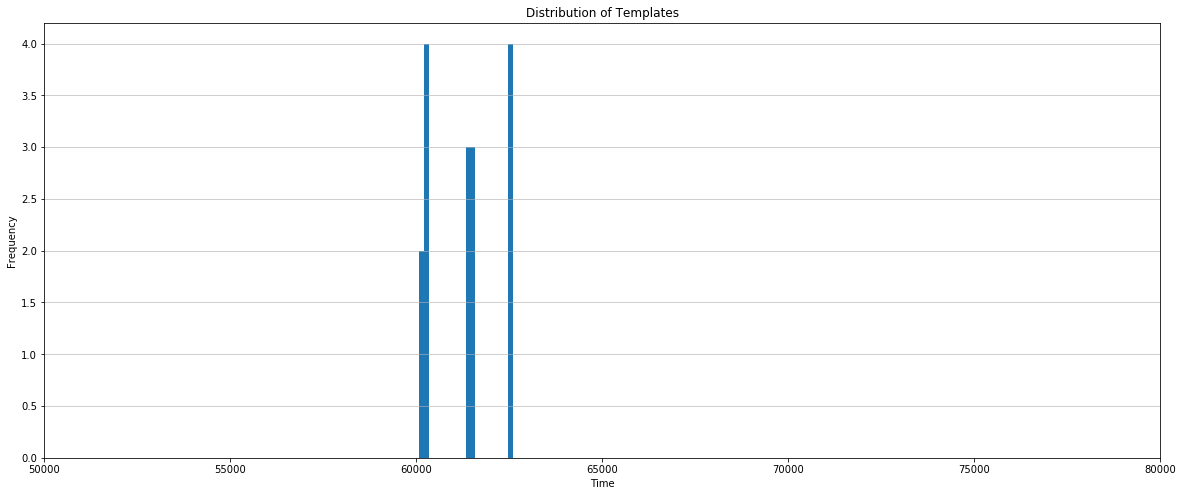

In [ ]:
import matplotlib.pyplot as plt
time_min = 50000
time_max = 80000
offsets = [   60084.   ,  60117.2  ,  60210.5  ,  60238.096,
		60238.596,  60238.096,  61424.2  ,  61423.796,  61423.796,
		61560.2  ,  61560.796,  61560.2  ,  62503.096,  62570.9  ,
		62572.176,  62589.2   ]
# 创建直方图
plt.figure(figsize=(20, 8))
plt.hist(offsets, bins=20)
plt.title('Distribution of Templates')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.xlim(time_min, time_max)
# 显示图形
plt.show()

### 批量保存事件

In [ ]:
# 定义时间范围
start_time = udt("2023-09-09T00:00:00.000000Z")
end_time = udt("2023-09-10T00:00:00.000000Z")

# 计算时间范围的秒数
time_range_seconds = (end_time - start_time)
offsets = [60084.   ,  60117.2  ,  60210.5  ,  60238.096,
		60238.596,  60238.096,  61424.2  ,  61423.796,  61423.796,
		61560.2  ,  61560.796,  61560.2  ,  62503.096,  62570.9  ,
		62572.176,  62589.2   ]
durations = [
 200,
 200,
 375,
 300,
 175,
 125,
 150,
 100,
 250,
 250,
 150,
 150,
 300,
 200,
 200,
 200
]
template_names = [
 'template_15021000.h5',
 'template_15029300.h5',
 'template_15052625.h5',
 'template_15059524.h5',
 'template_15059524_l.h5',
 'template_15059524_h.h5',
 'template_15355949_h.h5',
 'template_15355949_l.h5',
 'template_15355949.h5',
 'template_15390050.h5',
 'template_15390050_l.h5',
 'template_15390050_h.h5',
 'template_15625774.h5',
 'template_15642725.h5',
 'template_15643044.h5',
 'template_15647300.h5'
]


In [8]:
# 定义时间范围
start_time = udt("2023-09-09T00:00:00.000000Z")
end_time = udt("2023-09-10T00:00:00.000000Z")

# 计算时间范围的秒数
time_range_seconds = (end_time - start_time)
offsets = [63189.8   ]
durations = [
 150
]
template_names = [
 'template_15797450.h5'
]


In [9]:
data = utils.load_data('./Analysis/h5/Xs28/20230909_Xs28.h5')

In [11]:
for offset,duration,template_name in zip(offsets,durations,template_names):
	# 选择模板开始时间
	# 计算随机选择的时间
	template_start_time = start_time + offset

	# 将随机选择的时间转换为Unix时间戳
	template_start_time = template_start_time.timestamp


	# 假设 template_metadata 已经存在
	template_metadata = {
		'depth': [5.688252],
		'latitude': [44.500587],
		'longitude': [6.6641645],
		'origin_time': template_start_time, 
		'p_travel_times': [0],
		's_travel_times': [0],
		'stations': data['metadata']['stations']
	}

	# use the metadata to extract the waveforms of the template event
	# first, retrieve the origin time
	origin_time = template_metadata['origin_time']
	# this time is a timestamp in seconds
	print('Timestamp in seconds: {:.2f}, human readable date: {}'.\
			format(origin_time, udt(origin_time).strftime('%Y,%m,%d--%H:%M:%S')))

	# second, using the travel times we build the picks
	# for both the P and S waves
	tt_P = template_metadata['p_travel_times']
	tt_S = template_metadata['s_travel_times']

	# the picks, or the phase arrivals, are the sum
	# of the origin time and the travel times
	picks_P = origin_time + np.float64(tt_P)
	picks_S = origin_time + np.float64(tt_S)
	for s in range(len(template_metadata['stations'])):
		print('P pick on station {}: {}'.format(template_metadata['stations'][s],
												udt(picks_P[s]).strftime('%Y,%m,%d--%H:%M:%S')))
		print('S pick on station {}: {}'.format(template_metadata['stations'][s],
												udt(picks_S[s]).strftime('%Y,%m,%d--%H:%M:%S')))
		print('\n')
	# get the timestamp of the the beginning of your data
	# in this example, the data start at 2013,03,17 00:00:00
	T0 = udt('2023,09,09').timestamp
	# we can now define our picks as times relative to T0
	# and expressed in number of samples
	#
	# get the sampling rate:
	SR = data['metadata']['sampling_rate']
	# use the sampling rate to convert the times
	picks_P_samples = np.int32((picks_P - T0) * SR)
	picks_S_samples = np.int32((picks_S - T0) * SR)


	# let say we want to extract 1 second before the P wave
	# and 4 seconds before the S wave
	P_wave_buffer = np.int32(int(0.000005* time_range_seconds) * SR)
	S_wave_buffer = np.int32(int(0.000005* time_range_seconds) * SR)

	# these buffers define the beginning of the windows we want
	# to extract on each station
	beginning_P_windows = picks_P_samples - P_wave_buffer
	beginning_S_windows = picks_S_samples - S_wave_buffer
	print('We now have window start times in samples, relative to the beginning of the data array')
	for s in range(len(template_metadata['stations'])):
		print('P window start time on station {}: {:d} samples'.format(
			template_metadata['stations'][s],
			beginning_P_windows[s]))
		print('S window start time on station {}: {:d} samples'.format(
			template_metadata['stations'][s],
			beginning_S_windows[s]))
		print('\n')
	# extract the waveforms:
	# let say we only want to extract the S wave on the
	# horizontal components, and the P wave on the 
	# vertical components
	# we fix the template duration to 8 seconds
	n_stations = len(template_metadata['stations'])
	n_components = len(data['metadata']['components'])
	print("whole event time range seconds",time_range_seconds)
	template_waveforms = np.zeros((n_stations, n_components, duration),
								dtype=np.float32)
	print("template_waveforms shape",template_waveforms.shape)
	for s in range(n_stations):
		for c in range(n_components):
			if c < 2:
				# the data are organized such that c=0 and c=1 are 
				# the indexes for components north/south and east/west
				idx_start = beginning_S_windows[s]
				idx_end = idx_start + duration
			else:
				idx_start = beginning_P_windows[s]
				idx_end = idx_start + duration
			template_waveforms[s, c, :] = data['waveforms'][s, c, idx_start:idx_end]
	# we now keep in memory the relative time shifts between each channel,
	# which we call the moveouts
	# the reference time is the earliest start time of the windows
	reference_time = min(beginning_P_windows.min(), beginning_S_windows.min())
	moveouts_P = beginning_P_windows - reference_time
	moveouts_S = beginning_S_windows - reference_time

	moveouts = np.hstack( (moveouts_S.reshape(-1, 1),
						moveouts_S.reshape(-1, 1),
						moveouts_P.reshape(-1, 1)) )
	print('The horizontal and vertical component moveouts are:')
	for s in range(len(template_metadata['stations'])):
		print('vertical component moveout on station {}: {:d} samples'.format(
			template_metadata['stations'][s],
			moveouts_P[s]))
		print('horizontal component moveout on station {}: {:d} samples'.format(
			template_metadata['stations'][s],
			moveouts_S[s]))
		print('\n')
	# save the output in an h5 file


	os.system('mkdir output')
	with h5.File('./templates_new/'+template_name, mode='w') as f:
		f.create_dataset('depth', data=template_metadata['depth'])
		f.create_dataset('latitude', data=template_metadata['latitude'])
		f.create_dataset('longitude', data=template_metadata['longitude'])
		f.create_dataset('origin_time', data=template_metadata['origin_time'])
		f.create_dataset('p_travel_times', data=template_metadata['p_travel_times'])
		f.create_dataset('s_travel_times', data=template_metadata['s_travel_times'])
		
		f.create_dataset('moveouts_P', data=moveouts_P, compression='gzip')
		f.create_dataset('moveouts_S', data=moveouts_S, compression='gzip')
		f.create_dataset('sampling_rate', data=data['metadata']['sampling_rate'])
		f.create_dataset('waveforms', data=template_waveforms, compression='gzip')
		#这里一定要注意station的转换，byte_和str
		stations_bytes = [s.encode('utf-8') for s in template_metadata['stations']]
		f.create_dataset('stations', data=stations_bytes)
		print('We have just created a h5 database featuring the following datasets:\n', list(f.keys()))

Timestamp in seconds: 1694280789.80, human readable date: 2023,09,09--17:33:09
P pick on station 3010356: 2023,09,09--17:33:09
S pick on station 3010356: 2023,09,09--17:33:09


We now have window start times in samples, relative to the beginning of the data array
P window start time on station 3010356: 15797449 samples
S window start time on station 3010356: 15797449 samples


whole event time range seconds 86400.0
template_waveforms shape (1, 3, 150)
The horizontal and vertical component moveouts are:
vertical component moveout on station 3010356: 0 samples
horizontal component moveout on station 3010356: 0 samples




OSError: Unable to create file (unable to open file: name = './templates_new/template_15797450.h5', errno = 2, error message = 'No such file or directory', flags = 13, o_flags = 242)

## Plot the template event

In [ ]:
# tune some plotting parameters
font = {'family': 'serif', 
	'size': 18}
plt.rc('font', **font)

[]
200
[[0 0 0]]
200
[[0 0 0]]
200


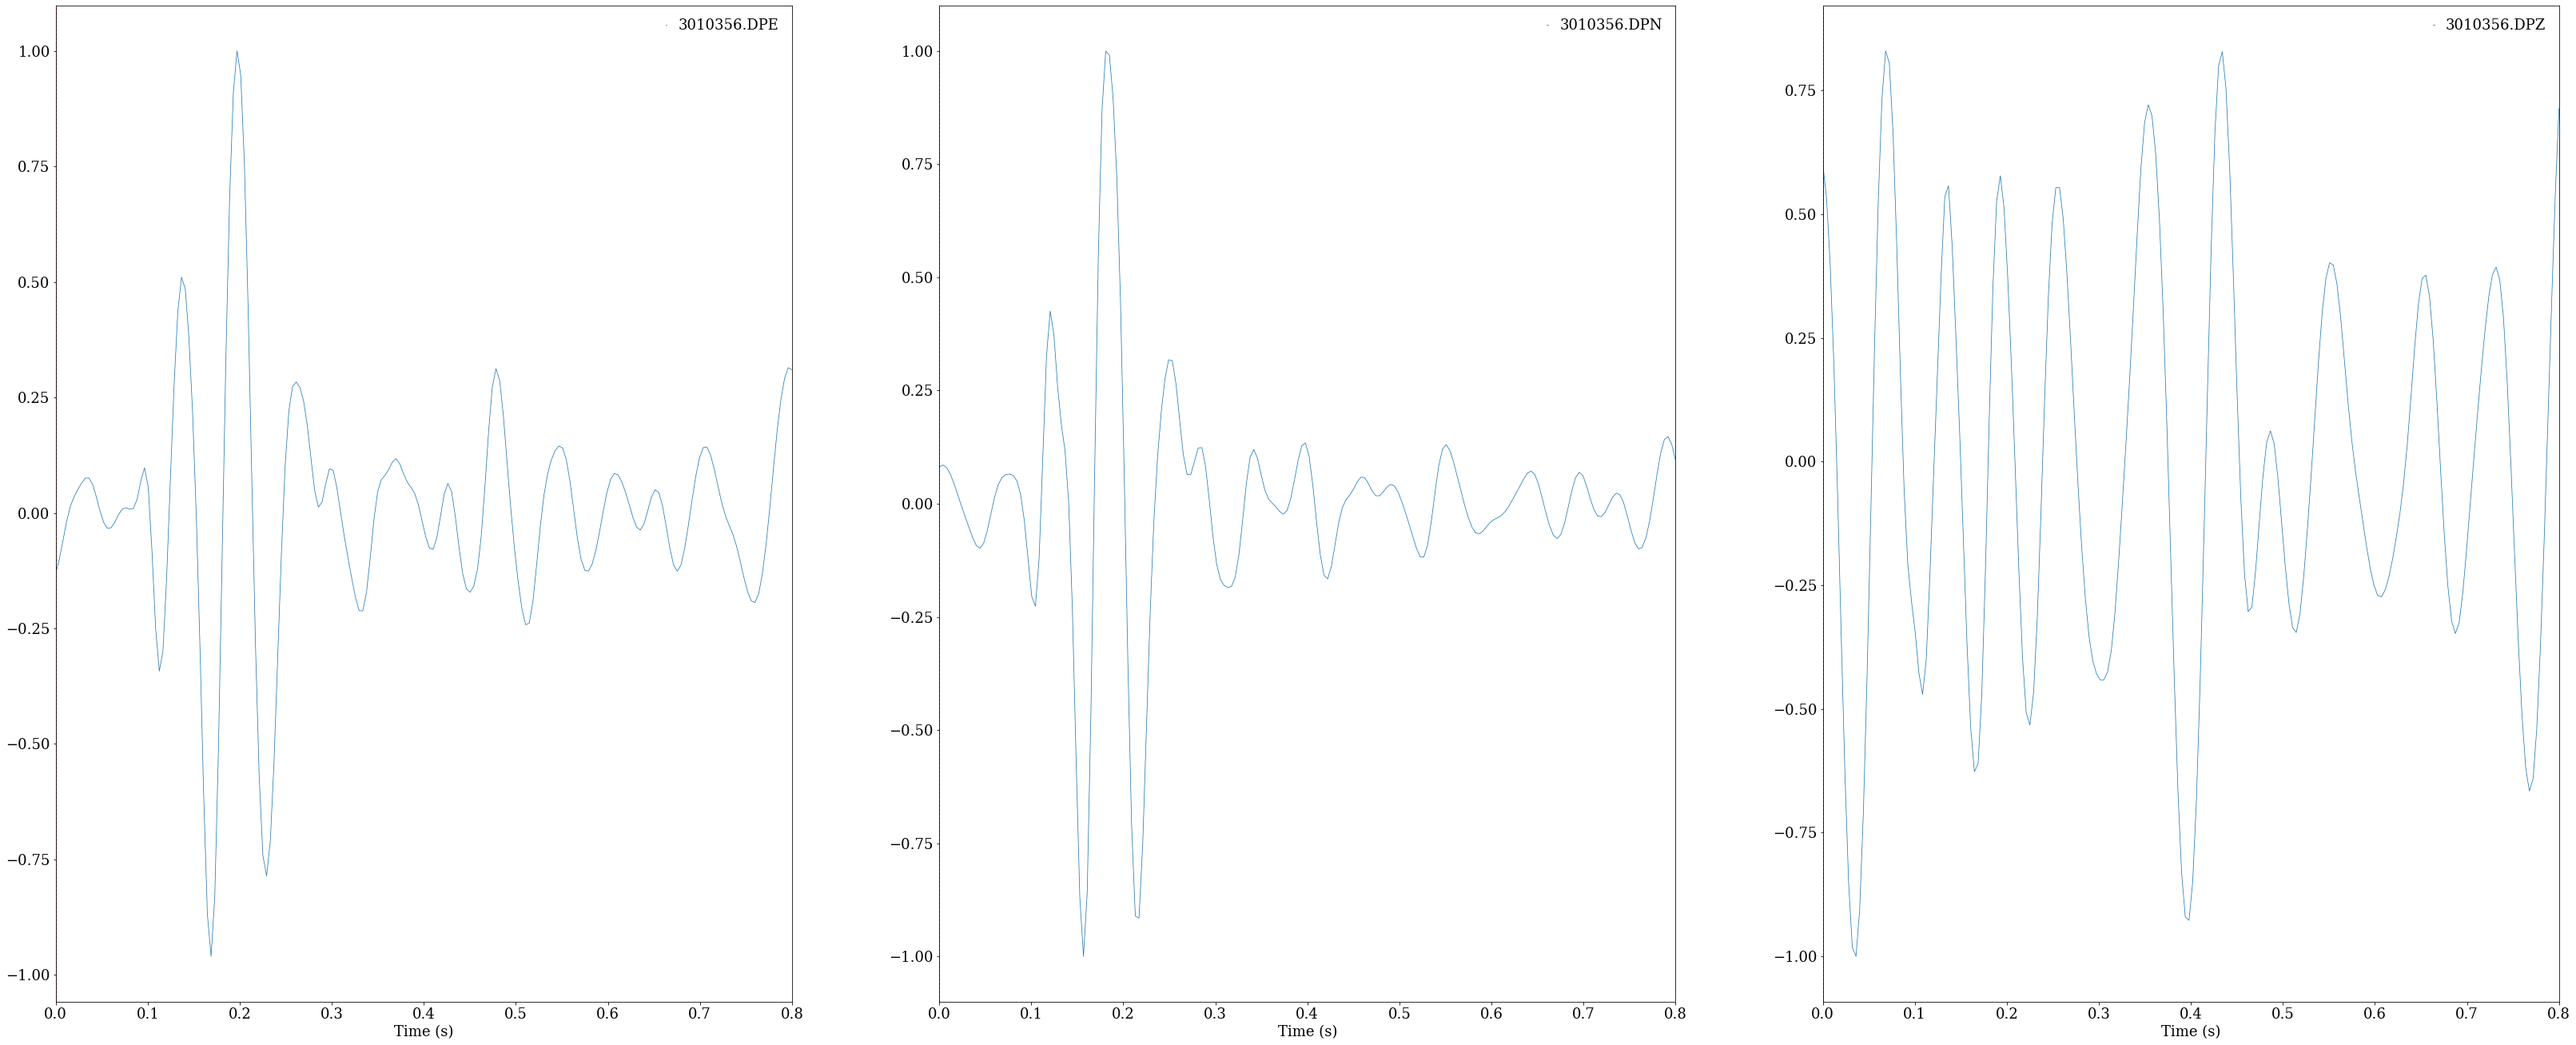

In [ ]:
# plot the template event
mv_min = 0.
mv_max = max(moveouts_P.max(), moveouts_S.max())
time_min = mv_min
time_max = (duration + mv_max) / SR # in seconds
figsize = (50, 20) # note: you can play with figsize to better fit your monitor
plt.figure('template_event', figsize=figsize)
for s in range(n_stations):
	for c in range(n_components):
		plt.subplot(n_stations, n_components, s * n_components + c + 1)
		# define time in seconds
		print(moveouts[s:c])
		print(duration)
		time = np.linspace(moveouts[s, c], moveouts[s, c] + duration, duration) / SR
		plt.plot(time, template_waveforms[s, c, :]/np.abs(template_waveforms[s, c, :]).max(), 
				 lw=0.75, label = '{}.{}'.\
				 format(template_metadata['stations'][s], data['metadata']['components'][c]))
		if c < 2:
			plt.axvline(time[S_wave_buffer], lw=1., ls='--', color='C3')
		else:
			plt.axvline(time[P_wave_buffer], lw=1., ls='--', color='C3')
		plt.legend(loc='best', frameon=False, handlelength=0.1)
		plt.xlim(time_min, time_max)
		if s == n_stations - 1:
			plt.xlabel('Time (s)')
		else:
			plt.xticks([])
plt.subplots_adjust(top=0.955,
		bottom=0.09,
		left=0.085,
		right=0.955,
		hspace=0.2,
		wspace=0.2)

The red dashed lines show the S-wave arrival (on the horizontal components, left two columns) and the P-wave arrival (on the vertical components, rightmost column) documented by the earthquake catalog.